## Ejercicio: **Transfer Learning y Fine Tuning**


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.utils import shuffle
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import layers
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from tensorflow.keras import Model
import pandas as pd

In [40]:
ruta = "train"

carpetas = [nombre for nombre in os.listdir(ruta) if os.path.isdir(os.path.join(ruta,nombre))]
print(carpetas)


['Braeburn', 'CrimsonSnow', 'Golden1', 'Golden2', 'Golden3', 'GrannySmith', 'PinkLady', 'Red1', 'Red2', 'Red3', 'RedDelicious', 'RedYellow1', 'RedYellow2']


In [41]:
class_names = carpetas
class_names_label = {class_name:i for i ,class_name in enumerate(class_names)}
class_names_label

{'Braeburn': 0,
 'CrimsonSnow': 1,
 'Golden1': 2,
 'Golden2': 3,
 'Golden3': 4,
 'GrannySmith': 5,
 'PinkLady': 6,
 'Red1': 7,
 'Red2': 8,
 'Red3': 9,
 'RedDelicious': 10,
 'RedYellow1': 11,
 'RedYellow2': 12}

In [42]:

IMAGE_SIZE = (100,100)
train_path1 = r"train"
test_path1 = r"test"

In [43]:
def read_data(path, im_size, class_names_label):
    X = []
    y = []

    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path,folder)
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path,file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, im_size)
            X.append(image)
            y.append(label)


    return np.array(X), np.array(y)


X_train, y_train = read_data(train_path1, IMAGE_SIZE, class_names_label)
X_test, y_test = read_data(test_path1, IMAGE_SIZE, class_names_label)

print(X_train.shape)
print(X_test.shape)


(6404, 100, 100, 3)
(2134, 100, 100, 3)


In [44]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [45]:
y_train[0:10]

array([ 5, 11,  5,  2, 10,  5,  4,  1, 10,  9])

In [46]:
import pandas as pd
pd.DataFrame(y_train).value_counts()

0 
12    672
0     492
3     492
5     492
7     492
8     492
11    492
10    490
4     481
2     480
6     456
1     444
9     429
Name: count, dtype: int64

In [47]:
X_train.max()

255

Red1


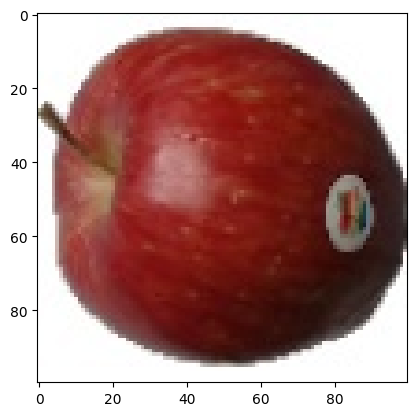

In [48]:
import matplotlib.pyplot as plt
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [49]:
input_shape = (100, 100, 3)

In [50]:
X_train_scal.shape

(6404, 100, 100, 3)

In [51]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=X_train.shape[1:])
base_model.trainable = False  # CONGELAMOS el modelo base . para luego ponerle true

model = Sequential([
    Input(shape=(input_shape)),
    tf.keras.layers.Lambda(preprocess_input), # esto transforma los 255 a 0 1. sin esto no funciona!
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(13, activation='softmax') #importante 13 ! había puesto 12 porque no habia contado bien.
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [52]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda_2 (Lambda)           (None, 100, 100, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 256)               327936    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 128)              

In [53]:
history_tl = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32)


Epoch 1/10
161/161 [==============================] - 5s 19ms/step - loss: 0.3233 - accuracy: 0.9003 - val_loss: 0.0133 - val_accuracy: 0.9992
Epoch 2/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0207 - accuracy: 0.9951 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 3/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0132 - accuracy: 0.9967 - val_loss: 0.0023 - val_accuracy: 1.0000
Epoch 4/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0147 - accuracy: 0.9955 - val_loss: 0.0067 - val_accuracy: 0.9984
Epoch 5/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0078 - accuracy: 0.9982 - val_loss: 2.8450e-04 - val_accuracy: 1.0000
Epoch 6/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0086 - accuracy: 0.9971 - val_loss: 5.0346e-04 - val_accuracy: 1.0000
Epoch 7/10
161/161 [==============================] - 2s 13ms/step - loss: 0.0277 - accuracy: 0.9920 - val_loss: 0.0574 - val_accuracy

67/67 [==============================] - 1s 8ms/step

--- Transfer Learning (MobileNetV2) Metricas: REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       164
           1       1.00      1.00      1.00       148
           2       1.00      1.00      1.00       160
           3       1.00      0.95      0.97       164
           4       0.95      1.00      0.97       161
           5       1.00      1.00      1.00       164
           6       0.85      0.84      0.84       152
           7       0.94      0.98      0.96       164
           8       0.85      0.89      0.87       164
           9       0.94      0.93      0.94       144
          10       1.00      1.00      1.00       166
          11       1.00      0.87      0.93       164
          12       1.00      1.00      1.00       219

    accuracy                           0.96      2134
   macro avg       0.96      0.96      0.96      2134
weigh

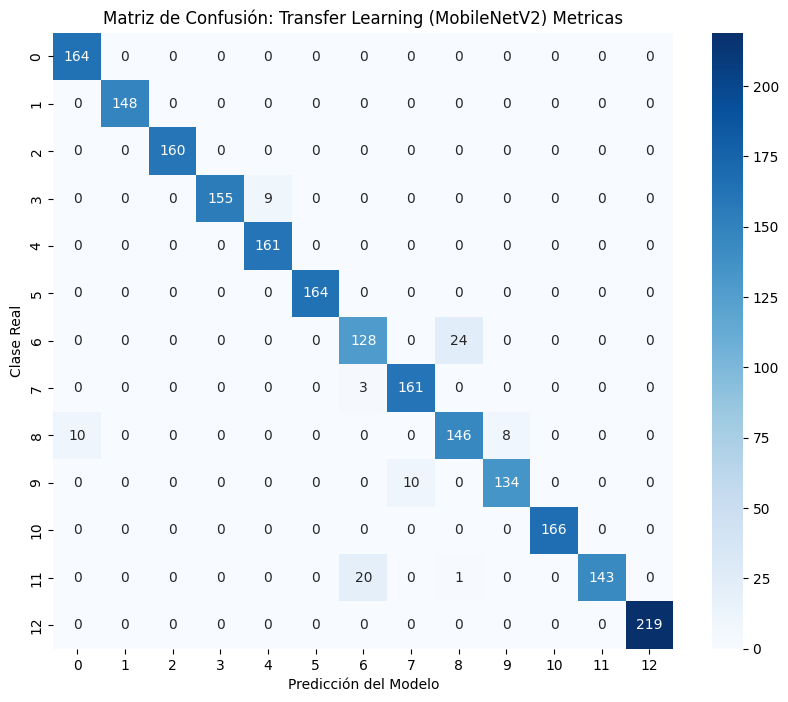

In [54]:
def mostrar_metricas(model, X, y, titulo):
    y_pred = np.argmax(model.predict(X), axis=1)
    
    print(f"\n--- {titulo}: REPORTE DE CLASIFICACIÓN ---")
    print(classification_report(y, y_pred))
    
    # 3. Dibujar la Matriz de Confusión
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {titulo}')
    plt.ylabel('Clase Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
mostrar_metricas(model, X_test, y_test, "Transfer Learning (MobileNetV2) Metricas")

In [55]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
history_ft = model.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=32)

Epoch 1/10
161/161 [==============================] - 6s 19ms/step - loss: 1.3682 - accuracy: 0.7306 - val_loss: 9.0040e-05 - val_accuracy: 1.0000
Epoch 2/10
161/161 [==============================] - 2s 14ms/step - loss: 0.1956 - accuracy: 0.9446 - val_loss: 3.5714e-05 - val_accuracy: 1.0000
Epoch 3/10
161/161 [==============================] - 2s 14ms/step - loss: 0.0793 - accuracy: 0.9754 - val_loss: 2.7400e-05 - val_accuracy: 1.0000
Epoch 4/10
161/161 [==============================] - 2s 15ms/step - loss: 0.0450 - accuracy: 0.9869 - val_loss: 5.4953e-05 - val_accuracy: 1.0000
Epoch 5/10
161/161 [==============================] - 2s 14ms/step - loss: 0.0397 - accuracy: 0.9900 - val_loss: 1.1062e-04 - val_accuracy: 1.0000
Epoch 6/10
161/161 [==============================] - 2s 14ms/step - loss: 0.0235 - accuracy: 0.9945 - val_loss: 8.5519e-05 - val_accuracy: 1.0000
Epoch 7/10
161/161 [==============================] - 2s 14ms/step - loss: 0.0255 - accuracy: 0.9939 - val_loss: 9.783

67/67 [==============================] - 1s 8ms/step

--- Fine-Tuning (MobileNetV2): REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       164
           1       1.00      1.00      1.00       148
           2       1.00      1.00      1.00       160
           3       0.94      0.82      0.88       164
           4       0.84      0.94      0.89       161
           5       1.00      1.00      1.00       164
           6       0.91      0.85      0.88       152
           7       0.86      0.98      0.91       164
           8       0.80      0.95      0.87       164
           9       0.99      0.82      0.90       144
          10       1.00      1.00      1.00       166
          11       1.00      0.93      0.97       164
          12       1.00      1.00      1.00       219

    accuracy                           0.94      2134
   macro avg       0.95      0.94      0.94      2134
weighted avg       0

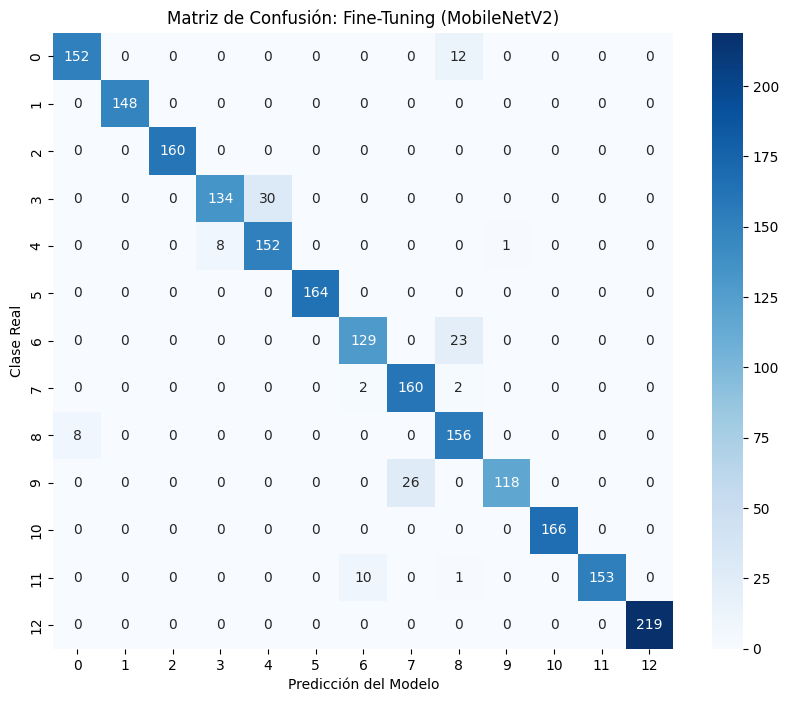

In [57]:
# Mostrar las metricas finales
mostrar_metricas(model, X_test, y_test, "Fine-Tuning (MobileNetV2)")